# LoRA Feasibility

## Imports and setup

In [18]:
import os
import pandas as pd
from PIL import Image
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

GPU available: True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


Build caption manifest
> *manifest = index file containing which the training script reads

In [19]:
attrs = pd.read_csv("../data/npc_attributes.csv")
npc = pd.read_csv("../data/npc.csv")[["id", "Location"]]
manifest = attrs.merge(npc, on="id", how="left")

def finalize_caption(row):
    base = row["caption"] if pd.notna(row["caption"]) else "an OSRS character"
    if pd.notna(row["Location"]):
        base += f", found in {row['Location']}"
    return base

manifest["final_caption"] = manifest.apply(finalize_caption, axis=1)
manifest[["id", "final_caption"]].sample(5)

,id,final_caption
1254,1254,"Eoin: Elf, male, found in Lletya"
3477,3477,"Security Guard: a goatee, a helmet, glasses, f..."
4231,4231,"Vyrelord: Vampyre, male, found in Ver Sinhaza"
1875,1875,"Hameln the Jester: Human, male, a goatee, unna..."
1644,1644,"Giral bat: Bat, found in Chambers of Xeric"


Filter to images that exist and split by type

In [20]:
chathead_ids = {int(f.split(".")[0]) for f in os.listdir("../data/chatheads")}
body_ids = {int(f.split(".")[0]) for f in os.listdir("../data/bodies")}

chathead_manifest = manifest[manifest["id"].isin(chathead_ids)].copy()
chathead_manifest["image_path"] = chathead_manifest["id"].apply(lambda i: f"../data/chatheads/{i}.png")

body_manifest = manifest[manifest["id"].isin(body_ids)].copy()
body_manifest["image_path"] = body_manifest["id"].apply(lambda i: f"../data/bodies/{i}.png")

print(len(chathead_manifest), len(body_manifest))

3473 4301


Save chathead manifest to disk (so the code runs faster)

In [21]:
chathead_manifest[["image_path", "final_caption"]].to_csv(
    "../data/chathead_lora_manifest.csv", index=False
)
print(len(chathead_manifest), "rows saved")

3473 rows saved


## EDA on Images in Chatheads and Bodies

Perform some EDA on image sizes (separate the analysis for chatheads vs bodies) to understand how much the spread is for images that need to be preprocessed

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_dims(folder):
    dims = []
    for f in os.listdir(f"../data/{folder}"):
        with Image.open(f"../data/{folder}/{f}") as im:
            dims.append(im.size)
    df = pd.DataFrame(dims, columns=["width", "height"])
    df["aspect_ratio"] = df["width"] / df["height"]
    return df

C:\Users\camiz\AppData\Local\Temp\ipykernel_18328\3860225644.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],


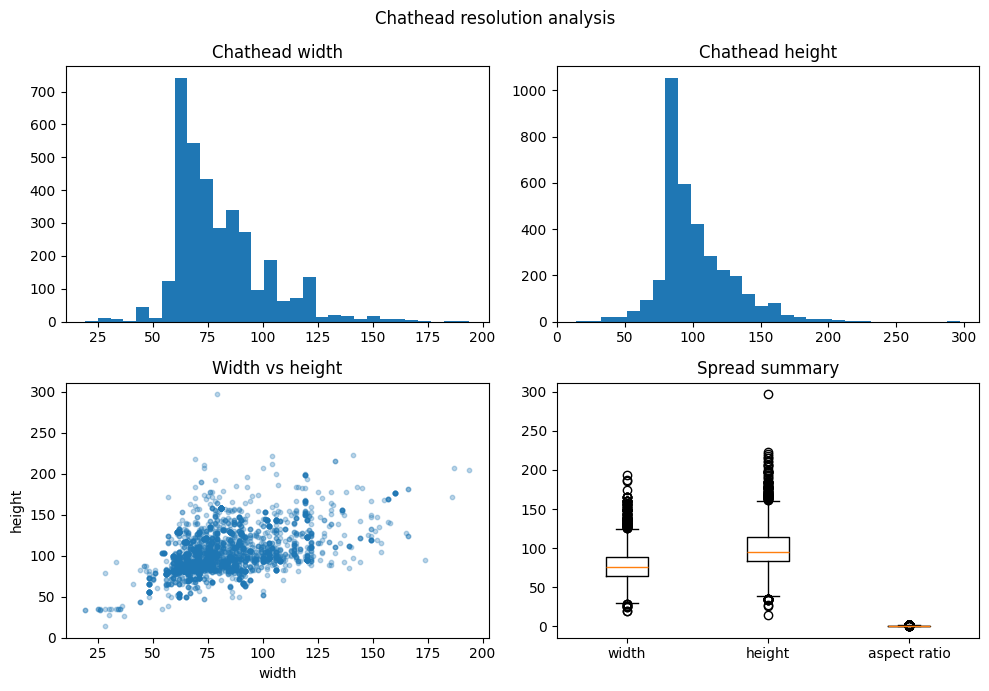

             width       height  aspect_ratio
count  3473.000000  3473.000000   3473.000000
mean     80.179672   100.936654      0.817713
std      20.579311    26.041763      0.197003
min      19.000000    14.000000      0.265993
25%      65.000000    83.000000      0.707071
50%      76.000000    95.000000      0.777174
75%      89.000000   114.000000      0.906780
max     194.000000   297.000000      2.000000


In [23]:
# Chatheads
chathead_dims = get_dims("chatheads")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(chathead_dims["width"], bins=30); axes[0,0].set_title("Chathead width")
axes[0,1].hist(chathead_dims["height"], bins=30); axes[0,1].set_title("Chathead height")
axes[1,0].scatter(chathead_dims["width"], chathead_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([chathead_dims["width"], chathead_dims["height"], chathead_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Chathead resolution analysis")
plt.tight_layout()
plt.savefig("../img/chathead_resolution_eda.png")
plt.show()

print(chathead_dims.describe())

> `Chathead` images are easier to preprocess first since most images tend to be the same size. It should be fairly easy to resize and pad without compromising information loss.

C:\Users\camiz\AppData\Local\Temp\ipykernel_18328\3266381031.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],


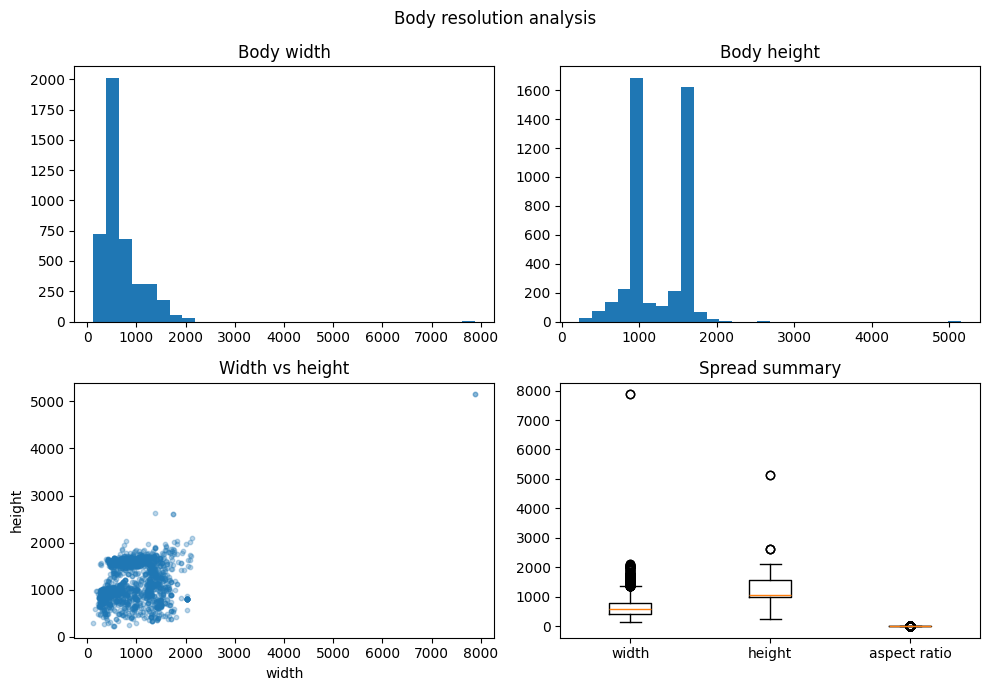

             width       height  aspect_ratio
count  4301.000000  4301.000000   4301.000000
mean    687.372704  1233.700070      0.608927
std     390.185444   361.397392      0.473975
min     128.000000   230.000000      0.173213
25%     420.000000   973.000000      0.376663
50%     575.000000  1058.000000      0.431959
75%     796.000000  1578.000000      0.605216
max    7880.000000  5150.000000      4.355499


In [24]:
# Bodies
body_dims = get_dims("bodies")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(body_dims["width"], bins=30); axes[0,0].set_title("Body width")
axes[0,1].hist(body_dims["height"], bins=30); axes[0,1].set_title("Body height")
axes[1,0].scatter(body_dims["width"], body_dims["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([body_dims["width"], body_dims["height"], body_dims["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Body resolution analysis")
plt.tight_layout()
plt.savefig("../img/body_resolution_eda.png")
plt.show()

print(body_dims.describe())

> Images in the `bodies` dataset are more spread out. Might be worth looking into the images that are outliers and see what the risks are if we preprocess these.

Dropped 2 outlier(s)


C:\Users\camiz\AppData\Local\Temp\ipykernel_18328\1700100249.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([body_dims_filtered["width"], body_dims_filtered["height"], body_dims_filtered["aspect_ratio"]],


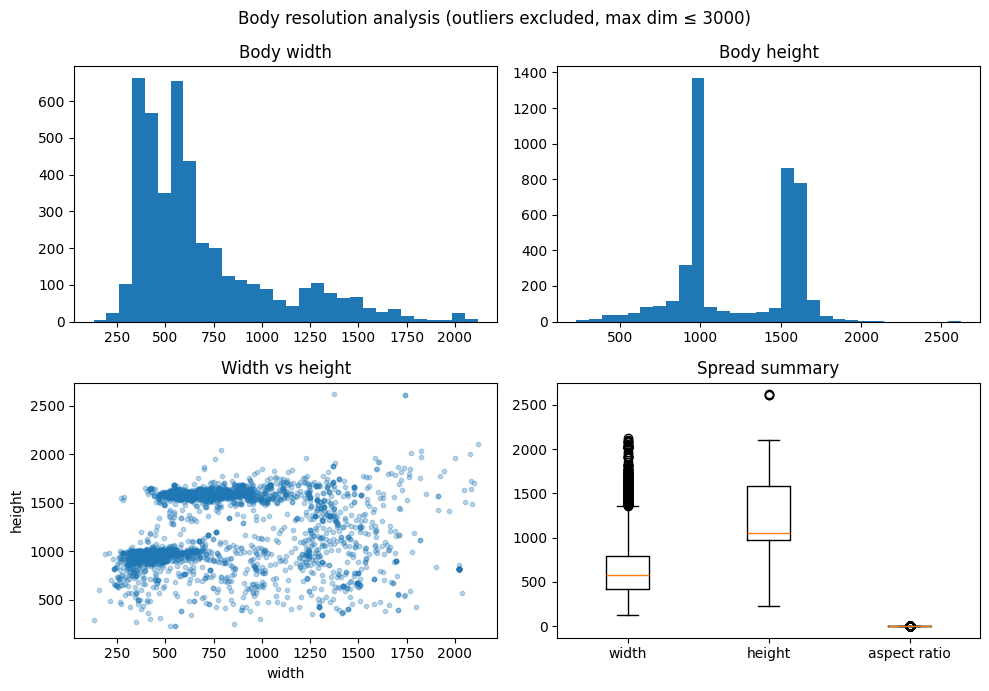

             width       height  aspect_ratio
count  4299.000000  4299.000000   4299.000000
mean    684.026518  1231.878111      0.608499
std     358.093361   351.466263      0.473669
min     128.000000   230.000000      0.173213
25%     420.000000   973.000000      0.376603
50%     575.000000  1055.000000      0.431934
75%     796.000000  1578.000000      0.604784
max    2120.000000  2620.000000      4.355499


In [31]:
# Bodies, excluding extreme outliers (max dimension > 3000)
body_dims_filtered = body_dims[(body_dims["width"] <= 3000) & (body_dims["height"] <= 3000)]
print(f"Dropped {len(body_dims) - len(body_dims_filtered)} outlier(s)")

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].hist(body_dims_filtered["width"], bins=30); axes[0,0].set_title("Body width")
axes[0,1].hist(body_dims_filtered["height"], bins=30); axes[0,1].set_title("Body height")
axes[1,0].scatter(body_dims_filtered["width"], body_dims_filtered["height"], alpha=0.3, s=10)
axes[1,0].set_title("Width vs height"); axes[1,0].set_xlabel("width"); axes[1,0].set_ylabel("height")
axes[1,1].boxplot([body_dims_filtered["width"], body_dims_filtered["height"], body_dims_filtered["aspect_ratio"]],
                   labels=["width", "height", "aspect ratio"])
axes[1,1].set_title("Spread summary")
plt.suptitle("Body resolution analysis (outliers excluded, max dim ≤ 3000)")
plt.tight_layout()
plt.savefig("../img/body_resolution_eda_filtered.png")
plt.show()

print(body_dims_filtered.describe())

> After removing the extreme outlier, the spread of the image dimensions looks a bit more interesting. It looks like some image types tend to cluster around a certain height--might be worth investigating after doing the feasibility of the chathead image generation. 

## More EDA on Chathead Images
> Find out what the smallest and largest images in the dataset look like so we can understand what padding strategy to apply, so that we don't accidentally cut off important features like hats, horns, etc.

In [25]:
def get_dims_with_id(folder):
    records = []
    for f in os.listdir(f"../data/{folder}"):
        npc_id = int(f.split(".")[0])
        with Image.open(f"../data/{folder}/{f}") as im:
            w, h = im.size
        records.append({"id": npc_id, "width": w, "height": h, "max_dim": max(w, h)})
    return pd.DataFrame(records)

chathead_dims_id = get_dims_with_id("chatheads")

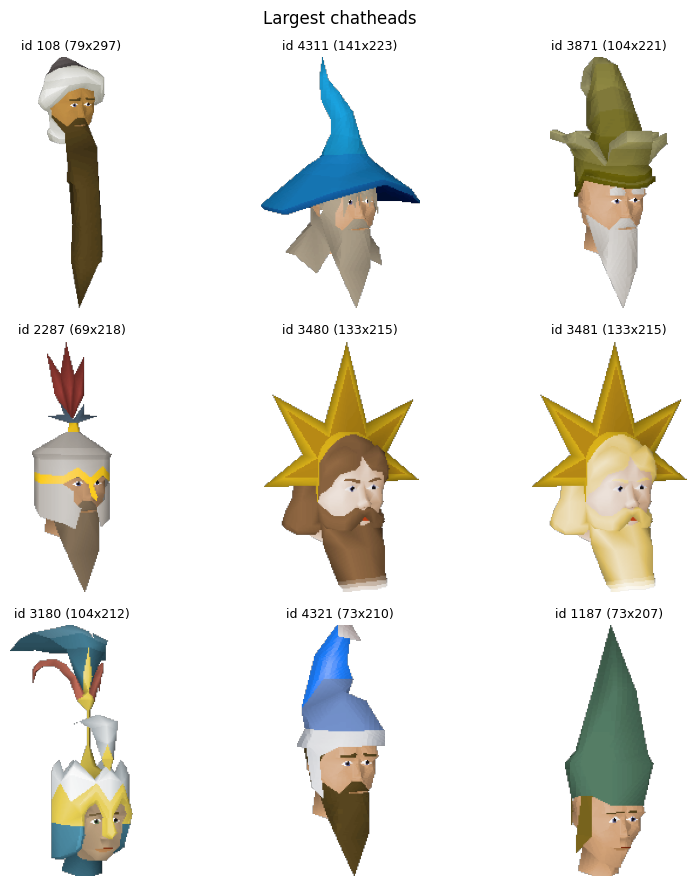

In [26]:
# Largest chatheads
n = 9
largest = chathead_dims_id.nlargest(n, "max_dim")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (_, row) in zip(axes.flat, largest.iterrows()):
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img)
    ax.set_title(f"id {row['id']} ({row['width']}x{row['height']})", fontsize=9)
    ax.axis("off")
plt.suptitle("Largest chatheads")
plt.tight_layout()
plt.show()

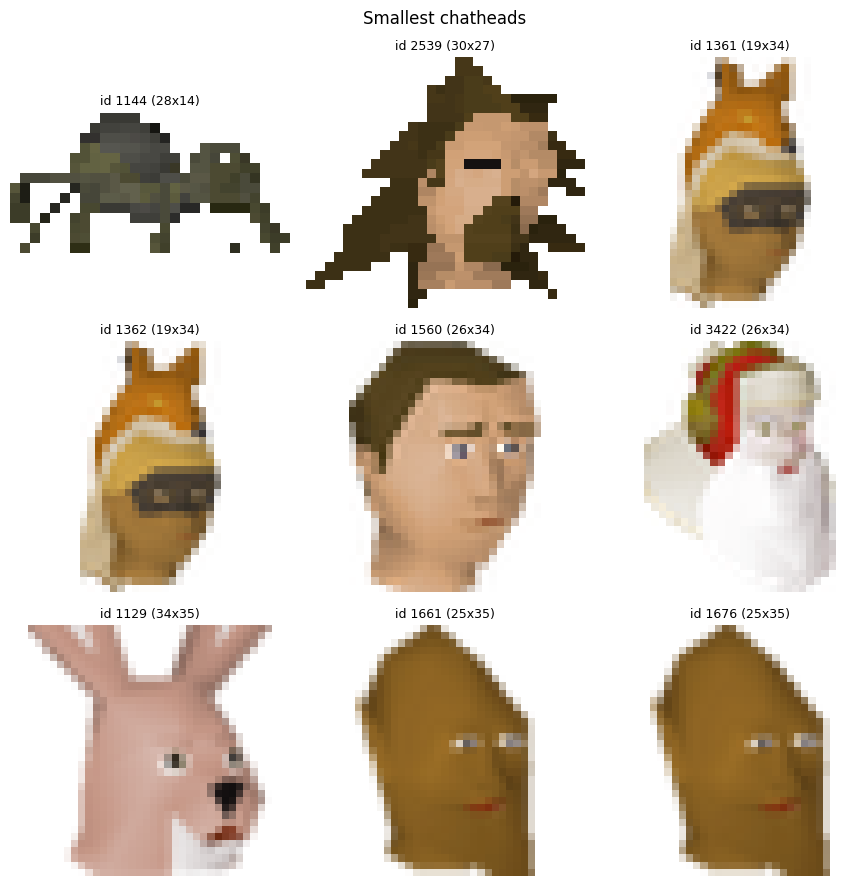

In [27]:
# Smallest chatheads
smallest = chathead_dims_id.nsmallest(n, "max_dim")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (_, row) in zip(axes.flat, smallest.iterrows()):
    img = Image.open(f"../data/chatheads/{row['id']}.png")
    ax.imshow(img)
    ax.set_title(f"id {row['id']} ({row['width']}x{row['height']})", fontsize=9)
    ax.axis("off")
plt.suptitle("Smallest chatheads")
plt.tight_layout()
plt.show()

> Based on this sample of smallest chathead images, I wanted to investigate the following things:
> 1. Is `id 1129`'s ears really cut off? And if so, are there other chatheads like this that might risk skewing the LoRA and other image generation model components (i.e. cutting off the ears might risk the model not learning about npcs with ears, etc.)
> 2. Are there other npc chatheads that have near-duplicate appearances like `id 1161` and `id 1676` --> upon doing some digging, it looks like there are visually similar npcs--while they have distinct ids and different lores/roles based on the `npc.csv` file, having visually similar images in the dataset can be a visually redundant risk for training purposes.
>
> It's for this reason, we need to detect visual near-duplicates before doing the preprocessing that way we can save on compute and load the appropriate data for modelling purposes.

### Detecting visually similar chatheads

In [28]:
npc = pd.read_csv("../data/npc.csv")[["id", "Name", "Race", "Location"]]
npc = npc.rename(columns={"Race": "Class"})

Use a threshold of 98% similarity first and trim it down if we want less clusters to train on. Clustering by class makes sense but since I lack OSRS domain knowledge, I want to test if I can capture more clusters based purely on visual similarity.

In [29]:
import numpy as np
import pandas as pd

emb = np.load("../data/chathead_embeddings.npy")
ids = np.load("../data/chathead_embedding_ids.npy")

norm_emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)
sim_matrix = norm_emb @ norm_emb.T

THRESHOLD = 0.98  # start high (near-identical); lower later if too few results
n = len(ids)
iu = np.triu_indices(n, k=1)
sims = sim_matrix[iu]
mask = sims >= THRESHOLD

dup_df = pd.DataFrame({
    "id_a": ids[iu[0][mask]],
    "id_b": ids[iu[1][mask]],
    "similarity": sims[mask]
}).sort_values("similarity", ascending=False)

print(f"{len(dup_df)} near-duplicate pairs found (threshold={THRESHOLD})")

# bring in names/captions for context (reuse npc loaded above -- already has Class renamed)
dup_df = dup_df.merge(npc, left_on="id_a", right_on="id", suffixes=("", "_a")).rename(columns={"Name":"Name_a","Class":"Class_a","Location":"Location_a"}).drop(columns="id")
dup_df = dup_df.merge(npc, left_on="id_b", right_on="id", suffixes=("", "_b")).rename(columns={"Name":"Name_b","Class":"Class_b","Location":"Location_b"}).drop(columns="id")

dup_df.to_csv("../data/chathead_near_duplicates.csv", index=False)
dup_df.head(20)

9390 near-duplicate pairs found (threshold=0.98)


,id_a,id_b,similarity,Name_a,Class_a,Location_a,Name_b,Class_b,Location_b
0,287,293,1.000001,Banker,Human,Bank,Banker,Werewolf,Canifis
1,287,298,1.000001,Banker,Human,Bank,Banker,Human,Draynor Village
2,287,317,1.000001,Banker,Human,Bank,Banker,Human,Tutorial Island
3,287,1520,1.000001,Banker,Human,Bank,Fry,Human,Rabbit Hole
4,298,1520,1.000001,Banker,Human,Draynor Village,Fry,Human,Rabbit Hole
5,298,317,1.000001,Banker,Human,Draynor Village,Banker,Human,Tutorial Island
6,293,298,1.000001,Banker,Werewolf,Canifis,Banker,Human,Draynor Village
7,293,1520,1.000001,Banker,Werewolf,Canifis,Fry,Human,Rabbit Hole
8,293,317,1.000001,Banker,Werewolf,Canifis,Banker,Human,Tutorial Island
9,317,1520,1.000001,Banker,Human,Tutorial Island,Fry,Human,Rabbit Hole


In [32]:
# Group into clusters of near-duplicates
import networkx as nx

G = nx.Graph()
G.add_edges_from(zip(dup_df["id_a"], dup_df["id_b"]))
clusters = list(nx.connected_components(G))
print(f"{len(clusters)} duplicate clusters found, sizes: {sorted([len(c) for c in clusters], reverse=True)[:10]}")

381 duplicate clusters found, sizes: [476, 176, 41, 33, 23, 23, 21, 21, 19, 19]


In [ ]:
# Cluster based on embeddings using HDBSCAN
# we use hierarchical density-based clustering to find clusters of similar embeddings, which can help identify groups of similar NPCs.
from sklearn.cluster import HDBSCAN

emb = np.load("../data/chathead_embeddings.npy")
ids = np.load("../data/chathead_embedding_ids.npy")
norm_emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)

clusterer = HDBSCAN(min_cluster_size=10, metric="euclidean")
cluster_labels = clusterer.fit_predict(norm_emb)

cluster_df = pd.DataFrame({"id": ids, "cluster": cluster_labels})
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"{n_clusters} clusters found, {n_noise} noise points (unclustered)")

39 clusters found, 2688 noise points (unclustered)


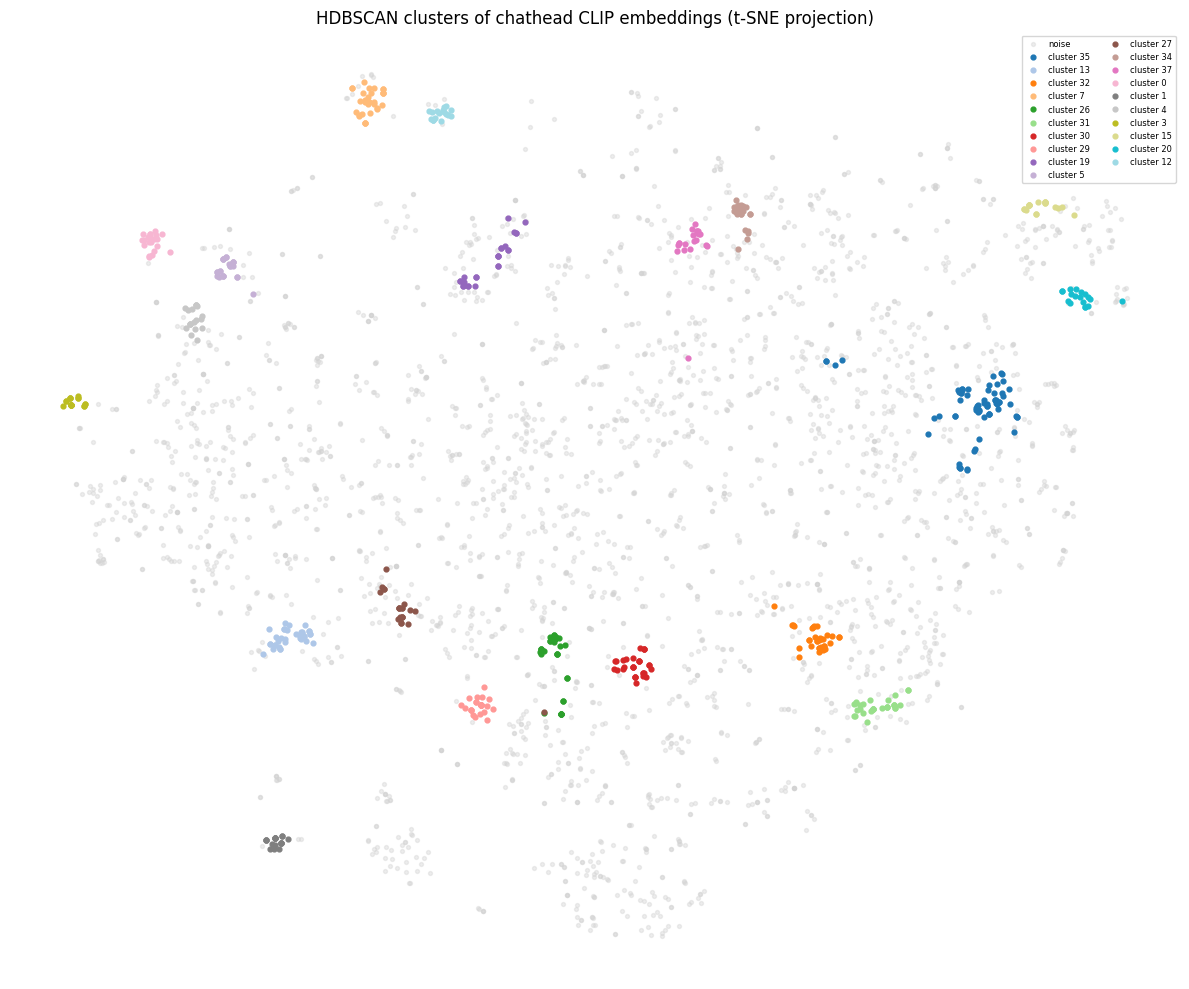

In [37]:
# Visualize HDBSCAN clusters
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded_2d = tsne.fit_transform(norm_emb)

fig, ax = plt.subplots(figsize=(12, 10))
noise_mask = cluster_labels == -1
ax.scatter(embedded_2d[noise_mask, 0], embedded_2d[noise_mask, 1], color="lightgray", s=8, alpha=0.4, label="noise")

top_clusters_for_color = cluster_sizes.head(20).index
cmap = plt.cm.tab20(np.linspace(0, 1, 20))
for i, c in enumerate(top_clusters_for_color):
    mask = cluster_labels == c
    ax.scatter(embedded_2d[mask, 0], embedded_2d[mask, 1], color=cmap[i], s=12, label=f"cluster {c}")

ax.set_title("HDBSCAN clusters of chathead CLIP embeddings (t-SNE projection)")
ax.axis("off")
ax.legend(fontsize=6, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("../img/chathead_hdbscan_clusters_tsne.png")
plt.show()

In [38]:
dup_check = dup_df.merge(cluster_df, left_on="id_a", right_on="id").rename(columns={"cluster": "cluster_a"}).drop(columns="id")
dup_check = dup_check.merge(cluster_df, left_on="id_b", right_on="id").rename(columns={"cluster": "cluster_b"}).drop(columns="id")

same_cluster_rate = (dup_check["cluster_a"] == dup_check["cluster_b"]).mean()
print(f"{same_cluster_rate:.1%} of near-duplicate pairs fall in the same HDBSCAN cluster")

# flag the exceptions -- worth eyeballing these specifically
mismatches = dup_check[dup_check["cluster_a"] != dup_check["cluster_b"]]
print(f"{len(mismatches)} near-dup pairs span two different HDBSCAN clusters")
mismatches[["id_a", "id_b", "similarity", "Name_a", "Name_b", "cluster_a", "cluster_b"]].head(10)

79.5% of near-duplicate pairs fall in the same HDBSCAN cluster
1925 near-dup pairs span two different HDBSCAN clusters


,id_a,id_b,similarity,Name_a,Name_b,cluster_a,cluster_b
81,3437,3438,1.000000,Sassilik,Sassilik,19,-1
455,2535,3146,1.000000,Major Collect,Private Pierreb,27,26
1356,1949,2863,0.997754,Hetty,Nora T. Hagg,11,-1
1385,1000,3429,0.997568,Disappointed mother,Sarah,-1,36
1405,4350,4351,0.997459,Wounded soldier,Wounded soldier,-1,34
1459,1874,2378,0.997174,Hambling,Lenny,-1,35
1537,1139,1534,0.996797,Edmond,Gabooty,-1,27
1606,1768,4060,0.996682,Guard,Treznor,-1,21
1607,3726,4060,0.996682,Soldier,Treznor,-1,21
1647,1000,2051,0.996557,Disappointed mother,Information clerk,-1,36


### Perform EDA on clusters identified

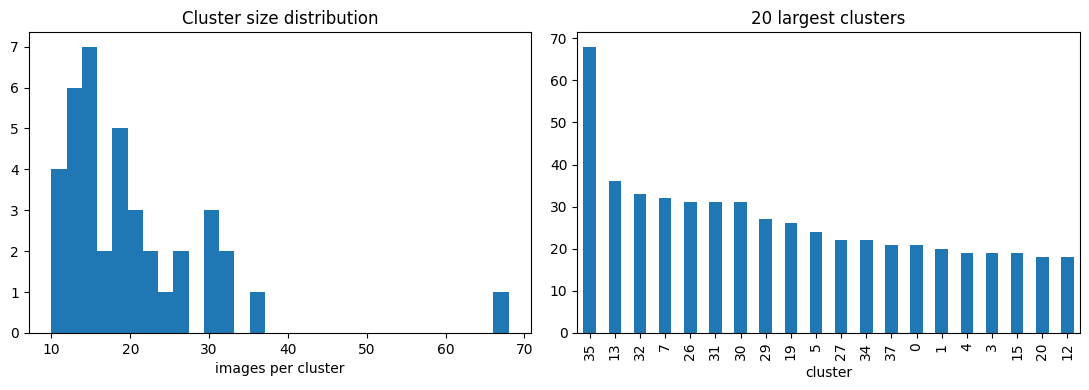

count    39.000000
mean     20.128205
std      10.694759
min      10.000000
25%      13.500000
50%      18.000000
75%      23.000000
max      68.000000
Name: count, dtype: float64


In [34]:
cluster_sizes = cluster_df[cluster_df["cluster"] != -1]["cluster"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(cluster_sizes, bins=30)
axes[0].set_title("Cluster size distribution")
axes[0].set_xlabel("images per cluster")

cluster_sizes.head(20).plot(kind="bar", ax=axes[1])
axes[1].set_title("20 largest clusters")
plt.tight_layout()
plt.savefig("../img/chathead_cluster_sizes.png")
plt.show()

print(cluster_sizes.describe())

In [35]:
# Validate clusters against metadata
merged = cluster_df.merge(npc, on="id", how="left")
top_clusters = cluster_sizes.head(10).index

for c in top_clusters:
    sub = merged[merged["cluster"] == c]
    top_class = sub["Class"].value_counts().head(3)
    print(f"Cluster {c} (n={len(sub)}): {dict(top_class)}")

Cluster 35 (n=68): {'Human': np.int64(66), 'Werewolf': np.int64(1)}
Cluster 13 (n=36): {'Gnome': np.int64(36)}
Cluster 32 (n=33): {'Human': np.int64(33)}
Cluster 7 (n=32): {'Dorgeshuun': np.int64(32)}
Cluster 26 (n=31): {'Human': np.int64(29), 'Dwarf': np.int64(2)}
Cluster 31 (n=31): {'Human': np.int64(31)}
Cluster 30 (n=31): {'Dwarf': np.int64(30), 'Dwarf ( Imcando-descendant )': np.int64(1)}
Cluster 29 (n=27): {'Dwarf': np.int64(25), 'Dwarf ( Imcando-descendant )': np.int64(2)}
Cluster 19 (n=26): {'Human': np.int64(26)}
Cluster 5 (n=24): {'Vampyre': np.int64(24)}


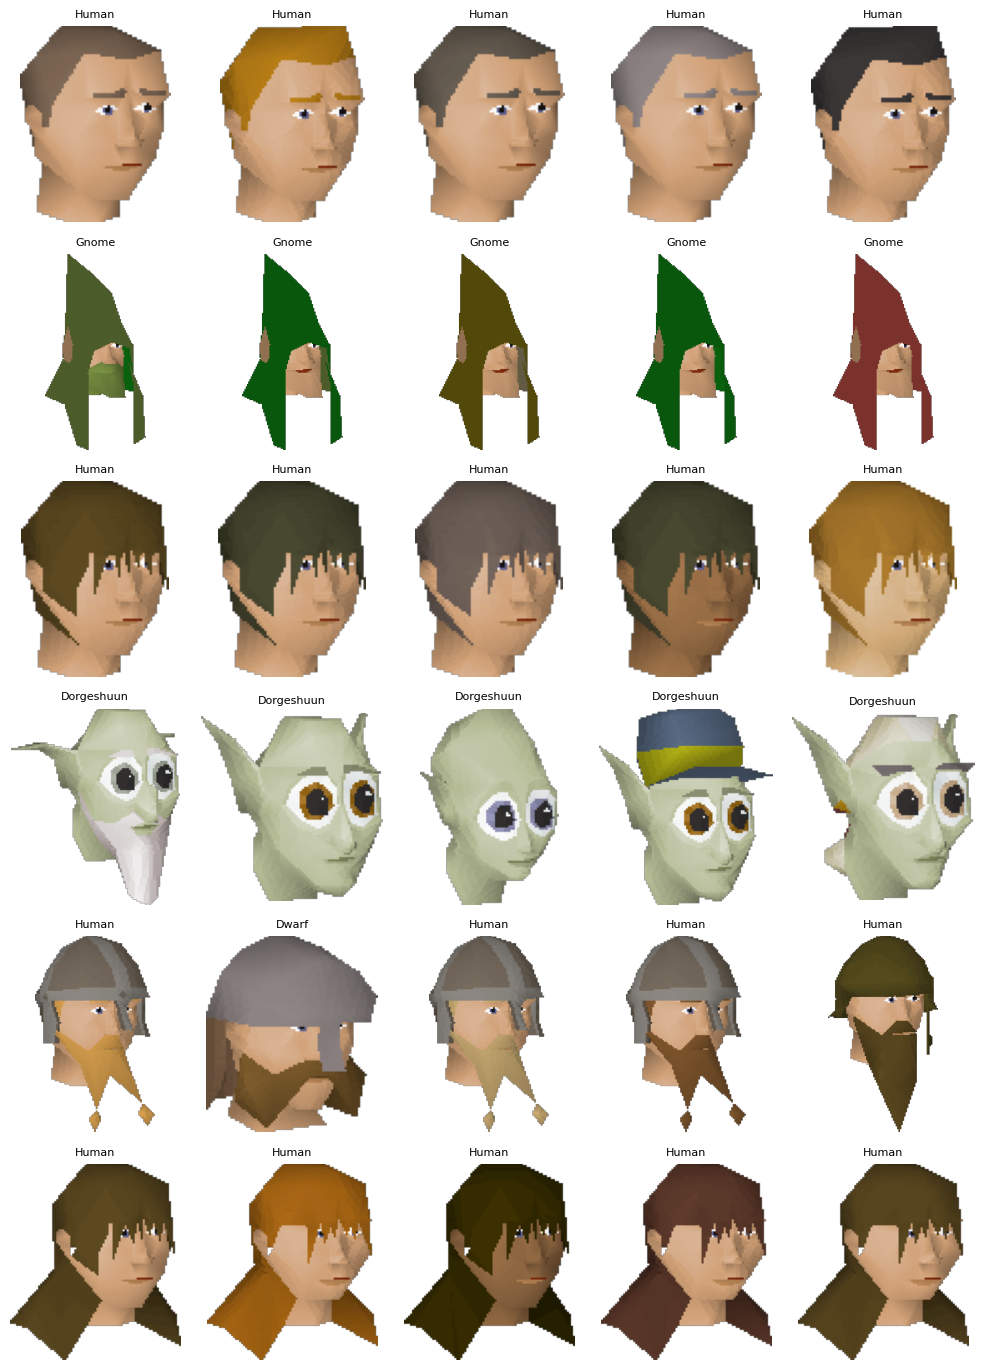

In [39]:
# Visual sanity check on largest clusters identified
fig, axes = plt.subplots(len(top_clusters[:6]), 5, figsize=(10, len(top_clusters[:6]) * 2.3))
for row, c in enumerate(top_clusters[:6]):
    sub = merged[merged["cluster"] == c]
    sample = sub.sample(min(5, len(sub)), random_state=1)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(f"../data/chatheads/{r['id']}.png")
        axes[row, col].imshow(img)
        axes[row, col].set_title(r["Class"], fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"cluster {c}", fontsize=9, rotation=0, labelpad=35)
plt.tight_layout()
plt.savefig("../img/chathead_cluster_samples.png")
plt.show()

## Chatheads Image Preprocessing

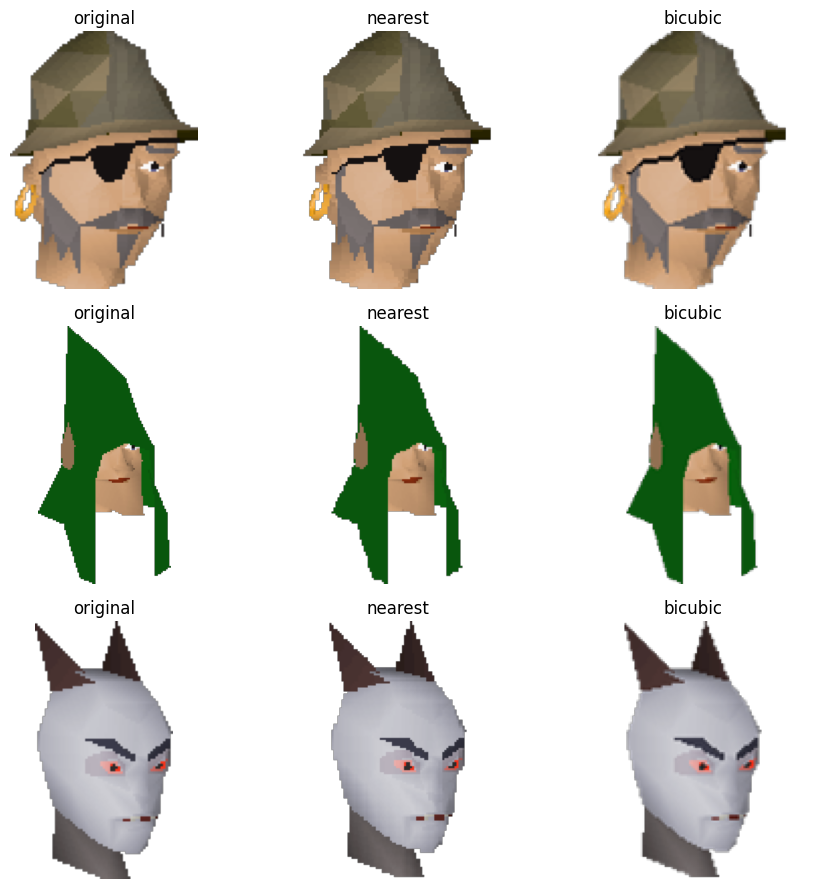

In [30]:
MIN_DIM = 30
TARGET_SIZE = 128

def resize_and_pad(img, target_size=TARGET_SIZE, resample=Image.NEAREST):
    img = img.convert("RGBA")
    w, h = img.size
    scale = target_size / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = img.resize((new_w, new_h), resample)

    canvas = Image.new("RGBA", (target_size, target_size), (0, 0, 0, 0))
    paste_x = (target_size - new_w) // 2
    paste_y = (target_size - new_h) // 2
    canvas.paste(resized, (paste_x, paste_y), resized)
    return canvas

# quick visual test: nearest vs bicubic, on a few samples
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
sample_ids = chathead_manifest["id"].sample(3, random_state=1).tolist()
for row, npc_id in enumerate(sample_ids):
    img = Image.open(f"../data/chatheads/{npc_id}.png")
    axes[row, 0].imshow(img); axes[row, 0].set_title("original")
    axes[row, 1].imshow(resize_and_pad(img, resample=Image.NEAREST)); axes[row, 1].set_title("nearest")
    axes[row, 2].imshow(resize_and_pad(img, resample=Image.BICUBIC)); axes[row, 2].set_title("bicubic")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout()
plt.show()

> Based on the results, above **bicubic** looks the smoothest but nearest-neighbor looks truer to the OG OSRS art style. I'll experiment with nearest-neighbor first and see what the image generation output looks like.

### Using Nearest-Neighbor

## Appendix
> Extra info on my pipeline and workflow, for reference.

Pipeline Components Explained
1. VAE (Variational Autoencoder)
> Simple Explanation: An image compression tool, like a zip file for pixels.Functional Role: Standard $512 \times 512$ or $128 \times 128$ pixel images have too many dimensions for a GPU to denoise efficiently. The VAE Encoder compresses pixel space into a smaller "latent space" representation (reducing spatial dimensions by a factor of 8). The U-Net does all its work in this small latent space. Once denoising is finished, the VAE Decoder unpacks those latents back into visible RGB pixels.
2. CLIP Text Encoder
> Simple Explanation: A translator converting human words into spatial concepts.Functional Role: CLIP takes your text caption (e.g., "an OSRS wizard with a dark robe") and turns it into a mathematical vector representation. It doesn't generate images; it provides spatial "guidance instructions" to the U-Net so the output matches the text.
3. U-Net Denoiser
> Simple Explanation: The actual artist removing static to reveal an image.Functional Role: This is the core neural network. It takes a noisy latent vector, receives text vectors from CLIP via cross-attention, and predicts how much noise to subtract to get closer to a coherent latent image. This is what you fine-tune.

**Key Hyperparameters for Fine-Tuning & Troubleshooting**
> When troubleshooting bad outputs during LoRA fine-tuning, these are the primary parameters you adjust:

| Hyperparameter | What It Controls | Troubleshooting |
|----------------|------------------|-----------------|
|Impact LoRA Rank ($r$) | Dimensionality of the LoRA matrices ($A \cdot B$).| **Too Low** ($r=2\text{--}4$): Output looks generic; fails to capture fine OSRS features. <br> **Too High** ($r=32\text{--}64$): Overfits quickly, wastes VRAM, and can cause training instability.
|LoRA Alpha ($\alpha$) | Scaling factor applied to LoRA updates. | Acts as weight strength. Higher values force the model to prioritize the LoRA adapter over the base Stable Diffusion model. Standard practice: set $\alpha = r$ or $\alpha = 2r$.
|Learning Rate ($lr$)| Speed of weight adjustments (typically $10^{-4}$ to $10^{-5}$). | **Too High** ($>10^{-3}$): Output breaks into random color noise/artifacts. <br> **Too Low** ($<10^{-6}$): Model barely changes; output looks like default SD 1.5.
|Training Steps / Epochs | How long the model trains on the dataset. | **Underfitted**: Character shapes are smooth photorealistic humans instead of OSRS low-poly style.<br> **Overfitted**: Generates exact duplicates of training images, ignoring prompt text.
|Resolution | Target dimension fed to VAE ($128 \times 128$). | Mismatches between preprocessed padding and target dimensions cause severe stretching or blurriness.